# Cliff walking: training

Train Q-learning and SARSA independently, then inspect their saved plots and optional recordings. Parameters are editable below. Training starts only when `RUN_TRAINING=True`; running this notebook with its default flag creates no experiment artifacts. See [the section guide](README.md) for the task and output conventions.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "rl_project").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from IPython.display import Image, Markdown, Video, display
from rl_project.runtime import video_sort_key
from rl_project.discrete import validate_algorithms
ALGORITHM_LABELS = {"qlearning": "Q-learning", "sarsa": "SARSA"}
from Grid_cliff.grid_cliff_env import RandomCliffWalkingEnv
from rl_project.tabular import TabularAgent
from Grid_cliff.grid_cliff_algorithms import plot_comparison
from rl_project.runtime import Run

## Configuration

The canonical 5×16 map has a cliff between the start and goal. Falling gives −100 and returns to the start without terminating; reaching the goal terminates. The 200-step cutoff applies even on a fall and retains the value bootstrap. Actions are 0=up, 1=right, 2=down, 3=left.

`config.json` is written automatically inside each new run as a snapshot of the settings used. Edit this notebook, not that saved snapshot. Shortening the episode budget does not automatically accelerate the exploration schedule.

In [2]:
ALGORITHMS = ("qlearning", "sarsa")  # Select both, or e.g. ("sarsa",).
RUN_TRAINING = True
SEED = 0
NUM_EPISODES = 5000  # Budget for each selected algorithm.
MAX_ENV_STEPS = None  # Optional per-algorithm step budget; use NUM_EPISODES=None for steps only.
OUTPUT_ROOT = ROOT / "artifacts"
RECORD_EVERY = 500
LOG_EVERY = 500
SHOW_PROGRESS = True
COMPARISON_WINDOW = 100

# One common task for both algorithms.
ENV_KWARGS = {
    "layout": "canonical",
    "max_steps": 200,
    "map_seed": 34,  # Used only with layout="random"; the map then stays fixed.
    "n_cliffs": 12,  # Used only with layout="random".
    "render_mode": None,
}

# Independent algorithm settings: changing one does not change the other.
AGENT_KWARGS = {
    "qlearning": {
        "learning_rate": .1,
        "discount_factor": .99,
        "initial_epsilon": 1.,
        "epsilon_decay": .9 / 3000,
        "final_epsilon": .1,
    },
    "sarsa": {
        "learning_rate": .1,
        "discount_factor": .99,
        "initial_epsilon": 1.,
        "epsilon_decay": .9 / 3000,
        "final_epsilon": .1,
    },
}

## Train

Each selected algorithm gets a fresh agent and a separate run directory. Checkpoints and incremental CSV metrics are saved before plotting. Q-learning uses a greedy backup; SARSA executes the same next action that was sampled for its backup.

The live total progress bar stays below summaries of each `LOG_EVERY` completed episodes, including a final partial block. Summary and recording labels start at episode 0; the total bar and CSV count completed episodes from 1.

In [3]:
agents = {}
results = {}
selected_algorithms = validate_algorithms(ALGORITHMS)
if RUN_TRAINING:
    for algorithm in selected_algorithms:
        display(Markdown(f"### {ALGORITHM_LABELS[algorithm]} training"))
        env = RandomCliffWalkingEnv(**ENV_KWARGS)
        try:
            agent = TabularAgent(env, seed=SEED, environment="cliff", **AGENT_KWARGS[algorithm])
            result = agent.train(
                NUM_EPISODES, algorithm=algorithm, max_env_steps=MAX_ENV_STEPS,
                output_root=OUTPUT_ROOT, record_every=RECORD_EVERY,
                log_every=LOG_EVERY, show_progress=SHOW_PROGRESS,
            )
            agents[algorithm] = agent
            results[algorithm] = result
            print(f"Saved run: {result.run_dir}")
        finally:
            env.close()
else:
    print("Training not run. Set RUN_TRAINING=True to start fresh runs; no checkpoint was loaded.")

### Q-learning training

Saved run: /Users/anthonymc/Desktop/NAML_project/artifacts/cliff/qlearning/20260913T101607629849Z_seed0_64ef511c


### SARSA training

Saved run: /Users/anthonymc/Desktop/NAML_project/artifacts/cliff/sarsa/20260913T101618017619Z_seed0_e0ba56b5


## Inspect plots and recordings

Reward bands show rolling mean ± two rolling standard deviations within one run. Outcomes show rolling success rate; binary success/collision indicators are omitted. TD error and epsilon are learning diagnostics.

With `RECORD_EVERY=500`, separate greedy demonstrations run after training episodes 0, 500, 1000, and so on, producing `episode_0.mp4`, `episode_500.mp4`, etc. Episode 0 is the first completed training episode. Videos are capped at 300 frames and 800 pixels wide; the demonstration still runs to the actual episode boundary.

### Q-learning outputs

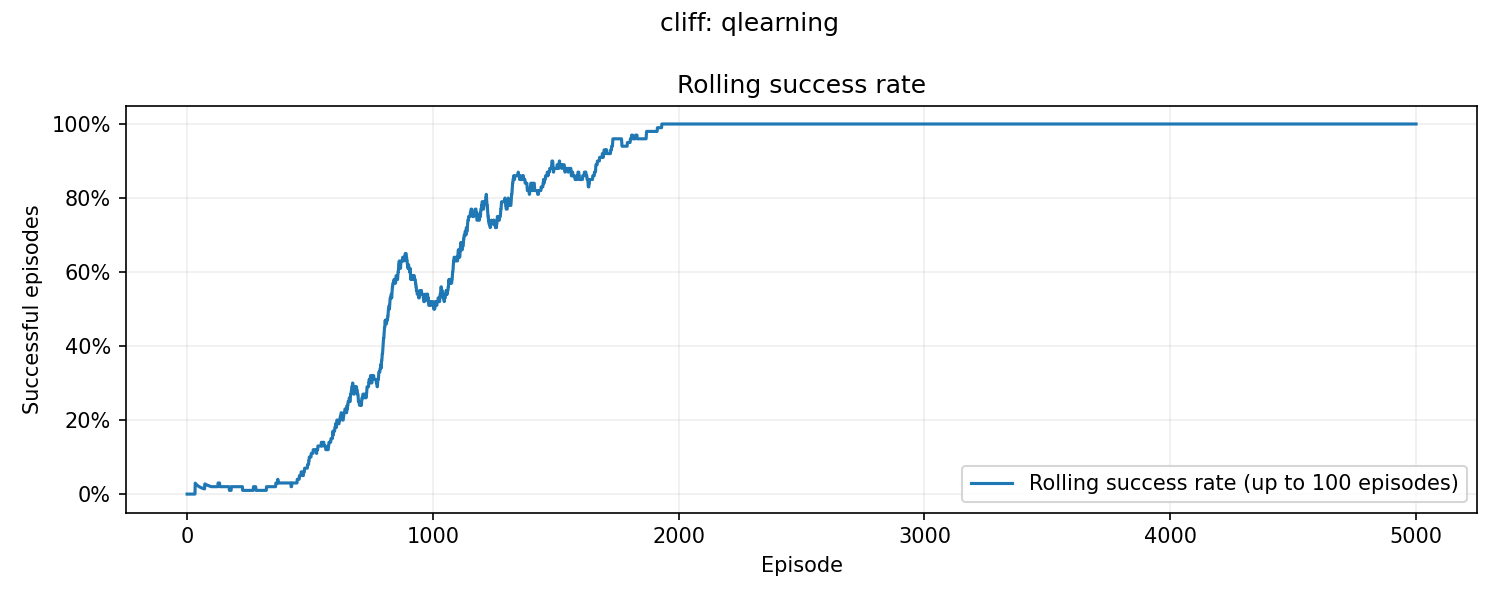

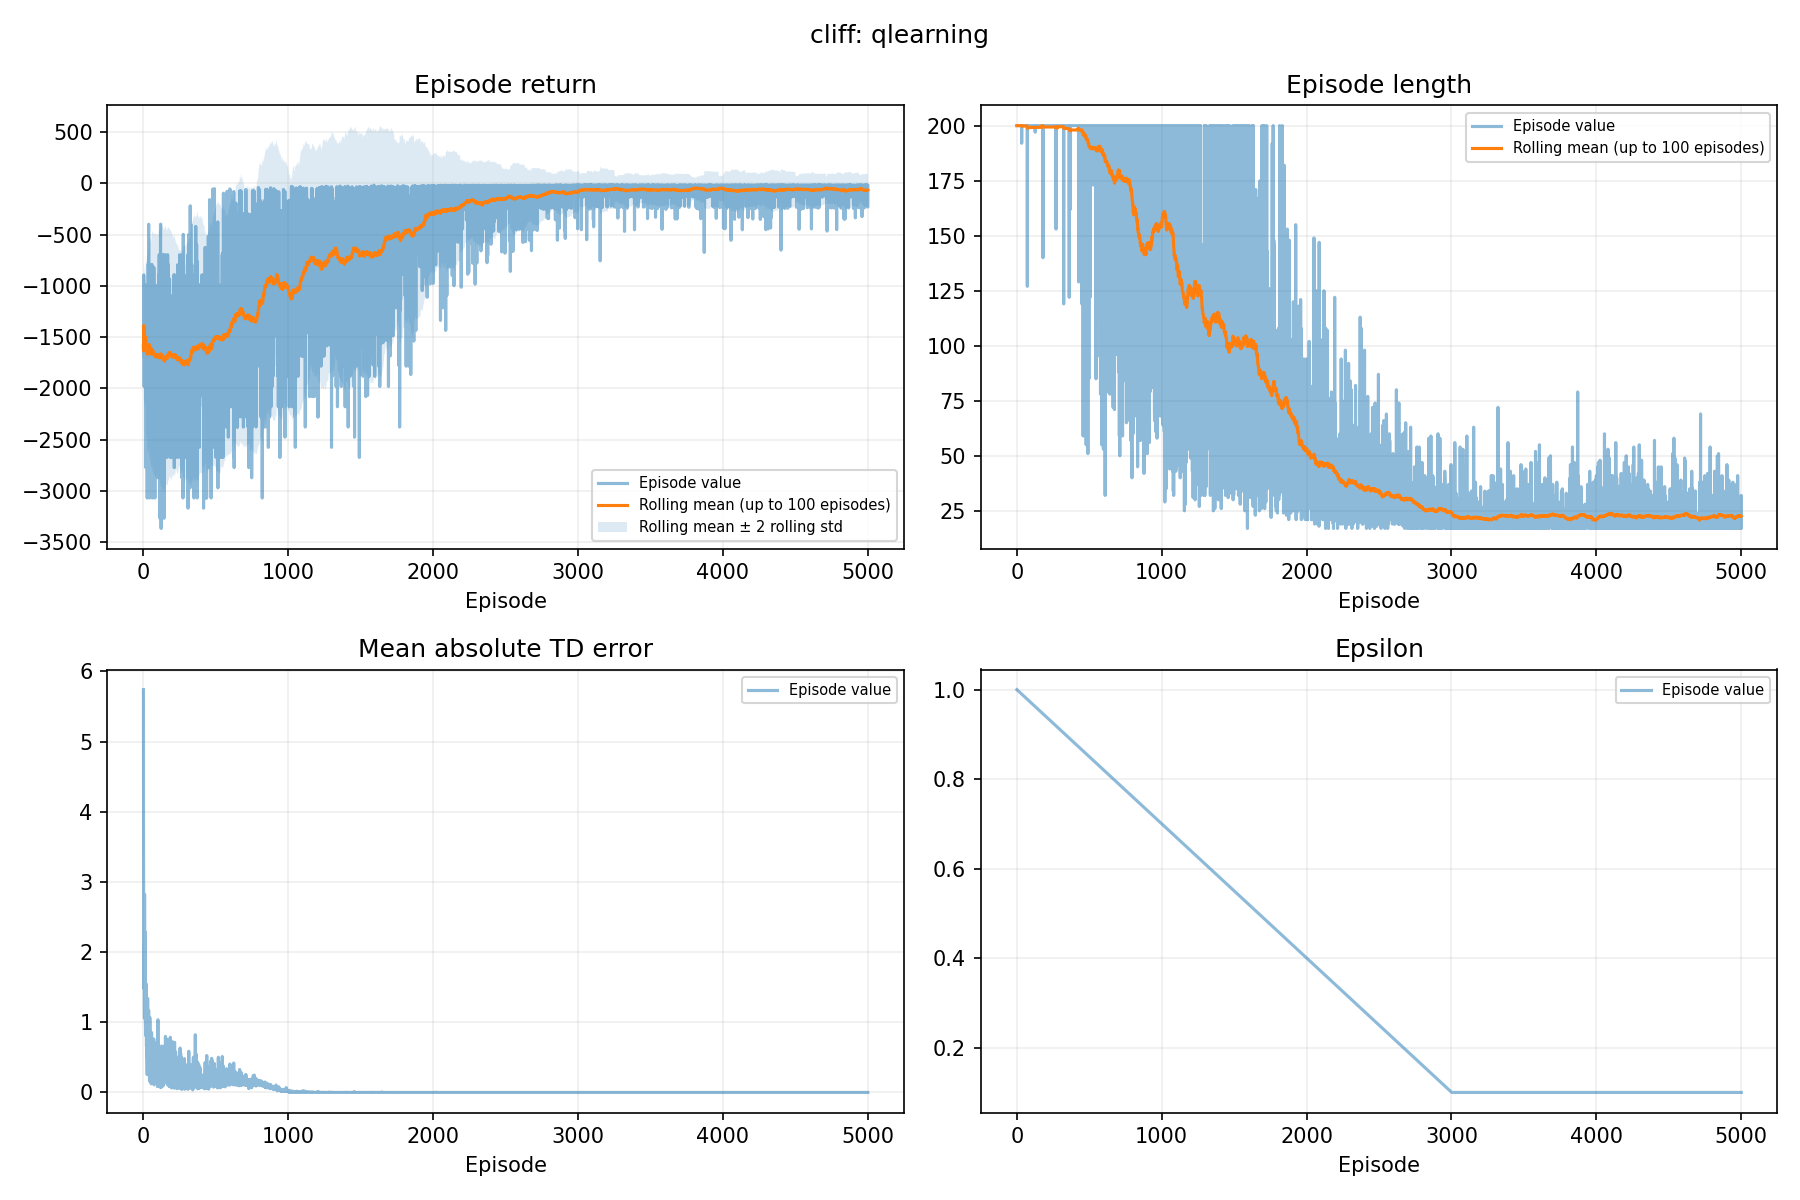

**episode_0.mp4**

**episode_500.mp4**

**episode_1000.mp4**

**episode_1500.mp4**

**episode_2000.mp4**

...

**episode_3000.mp4**

**episode_3500.mp4**

**episode_4000.mp4**

**episode_4500.mp4**

### SARSA outputs

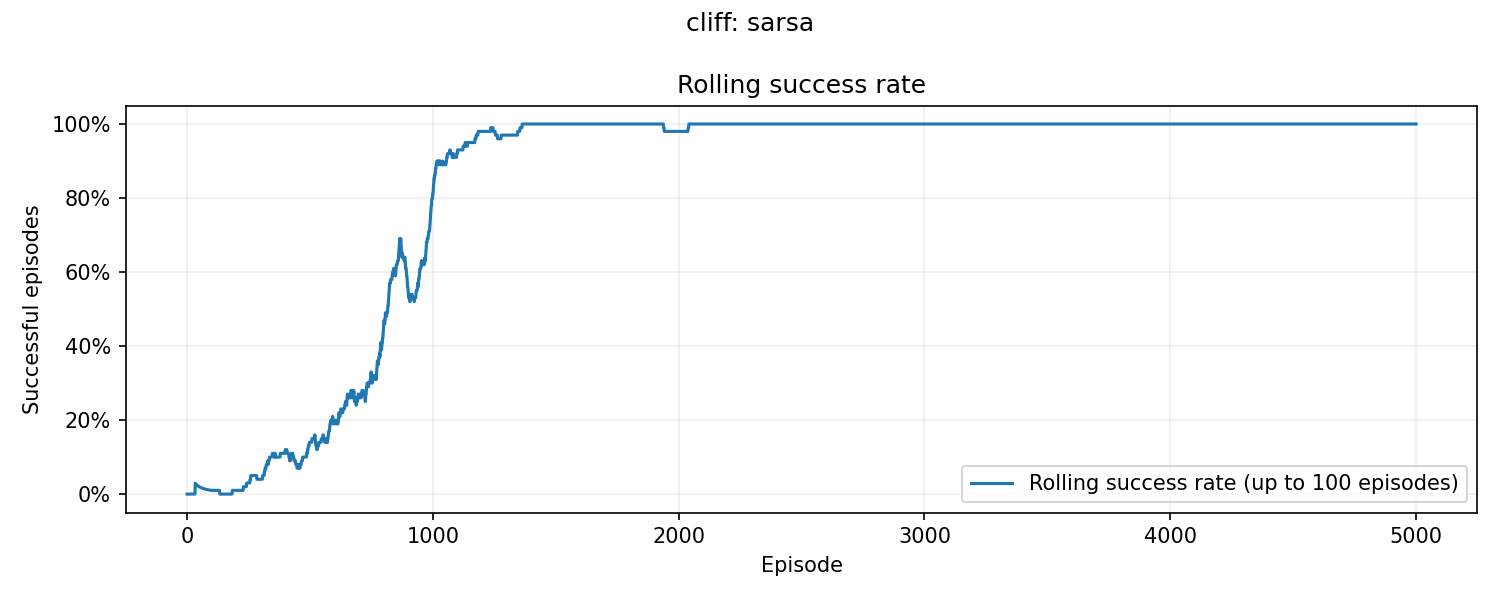

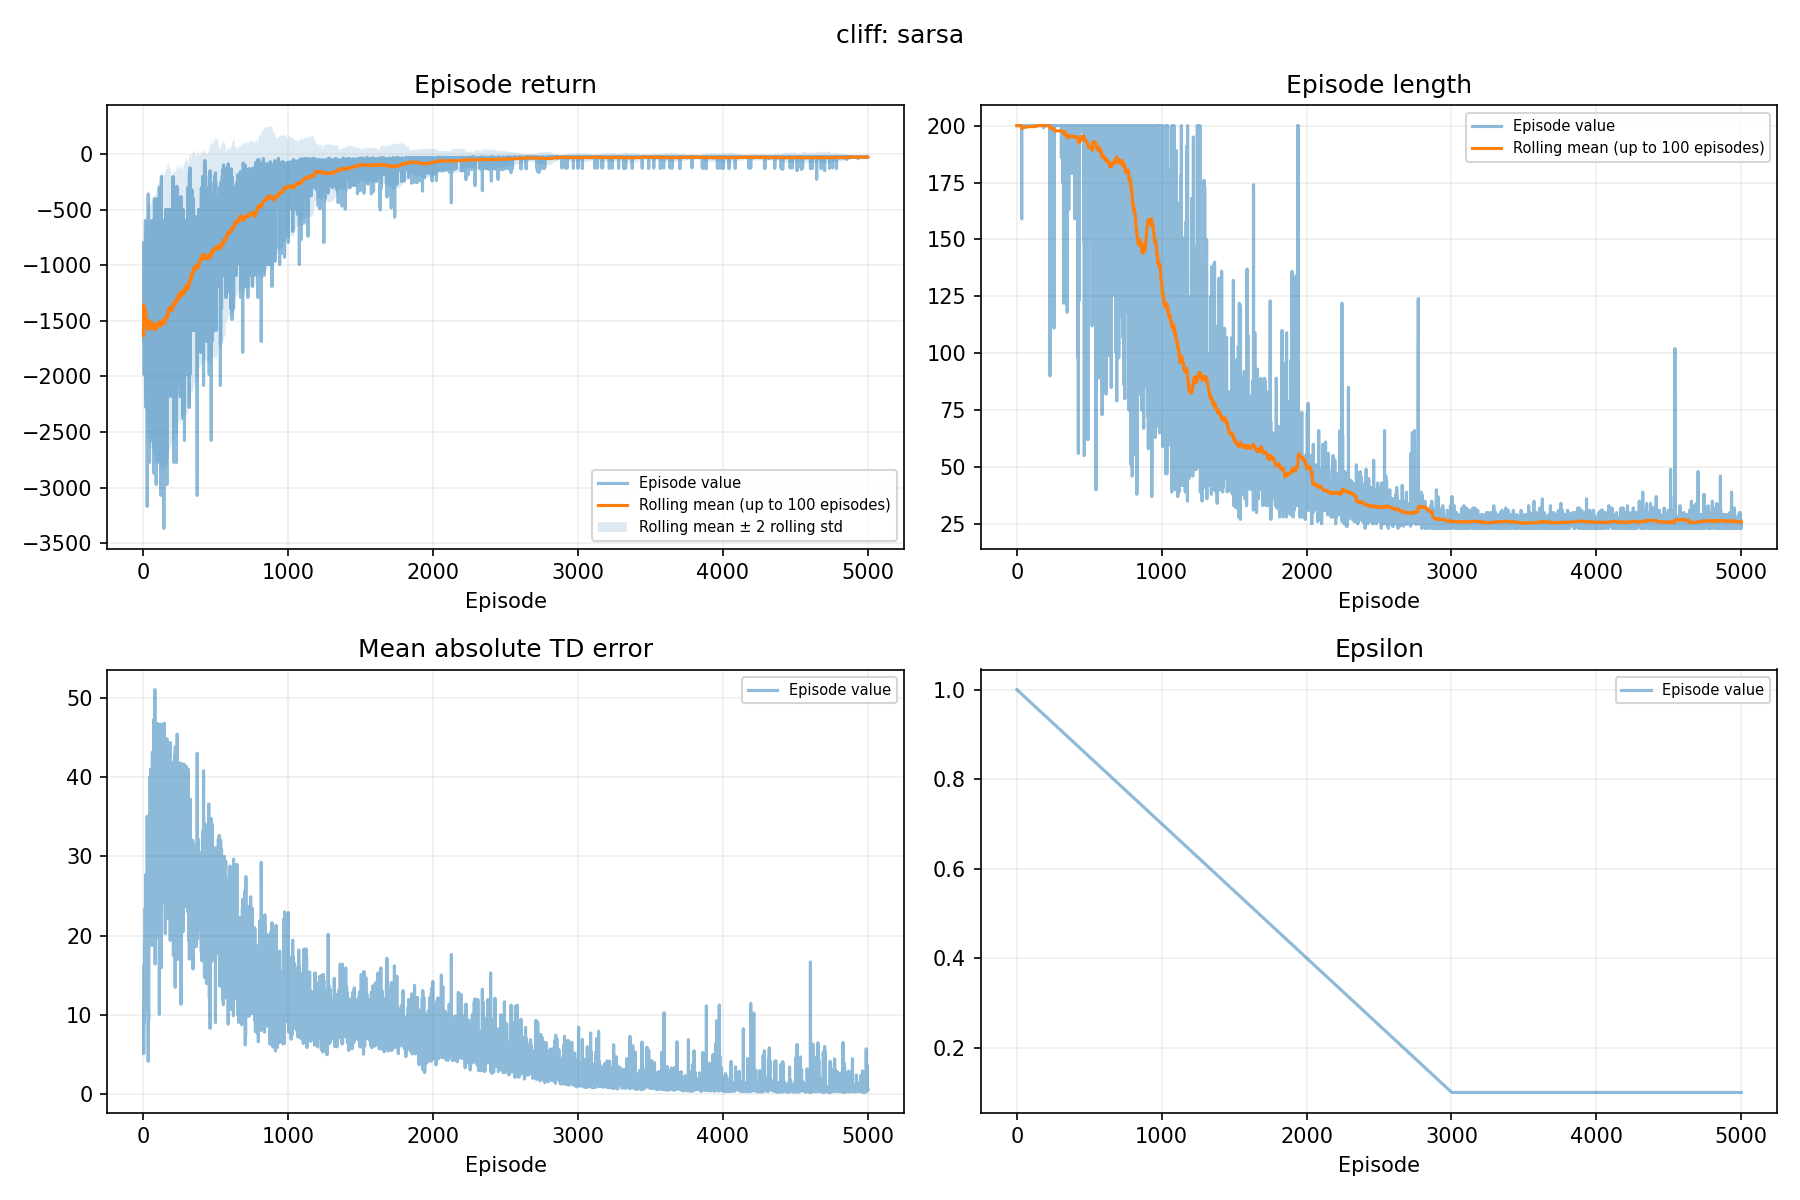

**episode_0.mp4**

**episode_500.mp4**

**episode_1000.mp4**

**episode_1500.mp4**

**episode_2000.mp4**

**episode_2500.mp4**

**episode_3000.mp4**

**episode_3500.mp4**

**episode_4000.mp4**

**episode_4500.mp4**

In [4]:
for algorithm, result in results.items():
    display(Markdown(f"### {ALGORITHM_LABELS[algorithm]} outputs"))
    for path in sorted((result.run_dir / "plots").glob("*.png")):
        display(Image(filename=str(path)))
    for path in sorted((result.run_dir / "videos/training").glob("*.mp4"), key=video_sort_key):
        display(Markdown(f"**{path.name}**"))
        display(Video(filename=str(path), embed=True))

## Q-learning versus SARSA during training

This comparison is created only when both algorithms completed in this execution. SARSA incorporates the consequences of future exploration into its backup and can favor a safer route. Q-learning evaluates greedy continuation, which can favor a short route near the cliff. A difference in training return under exploration is distinct from performance in the greedy evaluation notebook.

The comparison plots rolling return, goal-completion rate and episode length. It records the source run paths and the configured smoothing window.

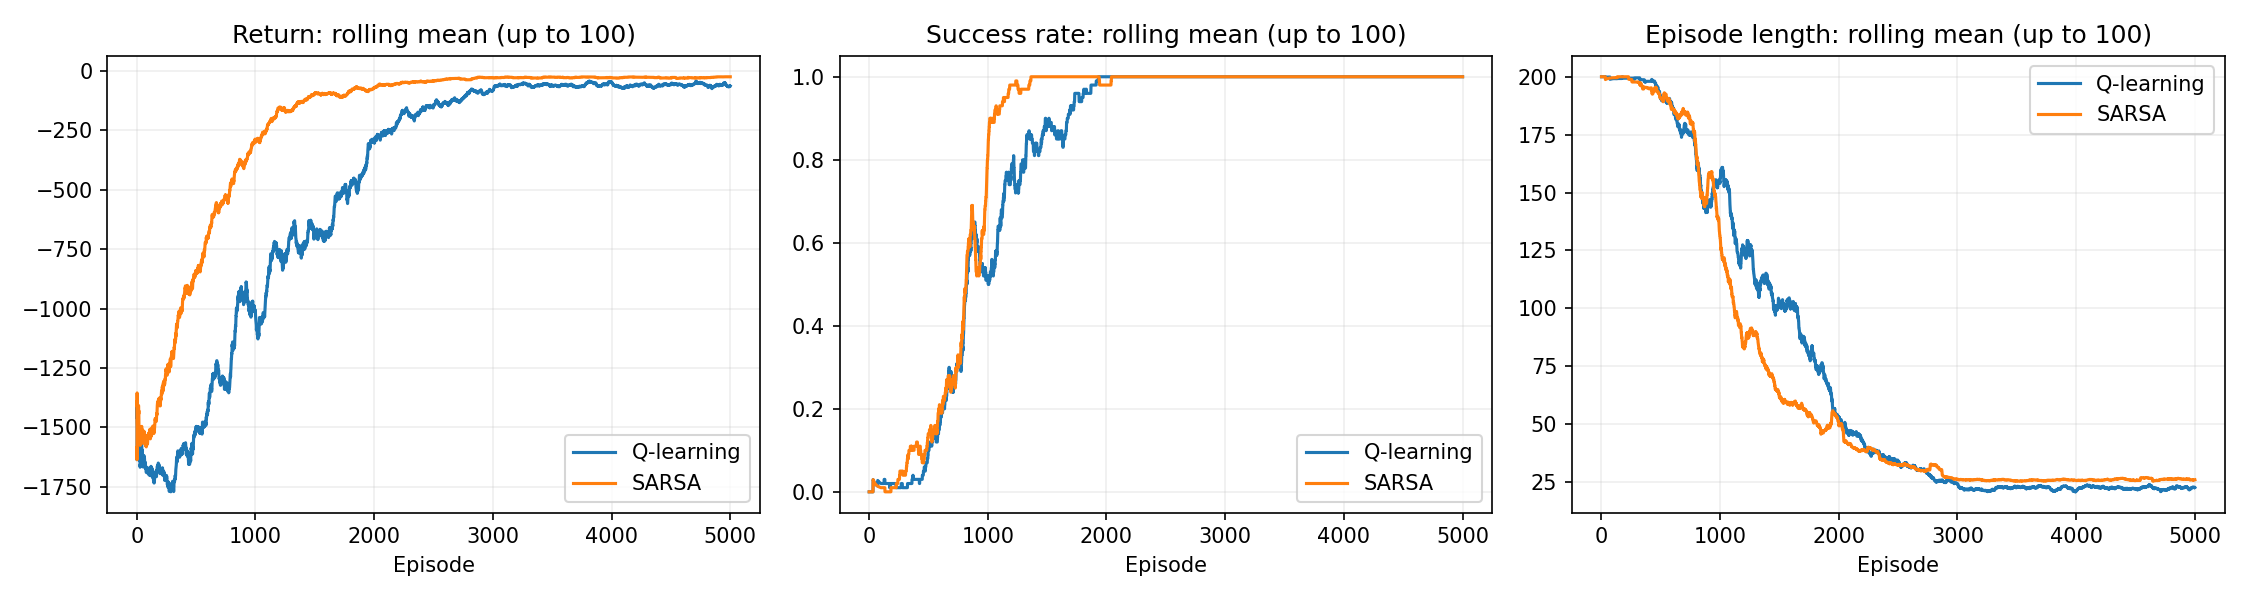

Saved comparison: /Users/anthonymc/Desktop/NAML_project/artifacts/cliff/comparison/20260913T101627625619Z_seed0_2c052c1e/plots/cliff_qlearning_vs_sarsa.png


In [5]:
comparison_result = None
if all(algorithm in results for algorithm in ("qlearning", "sarsa")):
    if COMPARISON_WINDOW < 1:
        raise ValueError("COMPARISON_WINDOW must be positive")
    comparison = Run(
        "cliff", "comparison", SEED,
        {"kind": "comparison", "source_runs": {a: str(r.run_dir) for a, r in results.items()},
         "window": COMPARISON_WINDOW}, OUTPUT_ROOT,
    )
    try:
        comparison_path = comparison.path / "plots/cliff_qlearning_vs_sarsa.png"
        plot_comparison(results["qlearning"], results["sarsa"], comparison_path, window=COMPARISON_WINDOW)
        comparison_result = comparison.finish()
    except BaseException:
        comparison.finish("failed")
        raise
    display(Image(filename=str(comparison_path)))
    print(f"Saved comparison: {comparison_path}")
else:
    print("Comparison unavailable: train both Q-learning and SARSA in this execution.")

## Evaluation and report export

Open [eval_grid_cliff.ipynb](eval_grid_cliff.ipynb) to evaluate selected checkpoints greedily and save presentation recordings.

For the report, review the completed comparison and copy `plots/cliff_qlearning_vs_sarsa.png` into the report figure directory. Update the matching report analysis using the saved metrics. [The report figure inventory](../Report/figures/README.md) identifies the pending slots. This notebook does not replace report evidence automatically.